# 06 - Final Evaluation and Conclusion

This notebook evaluates the models trained in the previous stages of the project: Regression and Time Series Forecasting. It compares their performance, visualizes the results, and concludes the project findings.

## 1. Imports
Importing necessary libraries for data manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

## 2. Load Saved Results
Since we are not retraining any models, we load the evaluation metrics of the models trained in previous notebooks. If saved metric files are unavailable, we recreate the metric DataFrames from the recorded experimental results.

In [6]:
# Creating DataFrames from extracted actual metrics
regression_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost'],
    'MAE': [0.7102, 0.0663, 0.0602, 0.0629, 0.0631, 0.0639],
    'RMSE': [0.8826, 0.1738, 0.1551, 0.1562, 0.1497, 0.1480],
    'R²': [-0.0135, 0.9607, 0.9687, 0.9682, 0.9708, 0.9715]
}
df_reg = pd.DataFrame(regression_data)

forecasting_data = {
    'Model': ['Manual ARIMA', 'Auto ARIMA', 'Manual SARIMA', 'Prophet'],
    'AIC': [51775.82, 53974.67, 48235.51, np.nan], 
    'MAE': [0.5775, 0.6241, 0.5065, 0.4884],
    'RMSE': [0.7011, 0.7364, 0.6832, 0.6388],
    'MAPE': [99.62, 108.58, 70.93, 73.37]
}
df_ts = pd.DataFrame(forecasting_data)

print("Actual metrics loaded successfully.")

Actual metrics loaded successfully.


## 3. Regression Model Comparison
Comparing the performance of various regression models to predict household power consumption based on features.

In [7]:
df_reg_sorted = df_reg.sort_values(by='RMSE').reset_index(drop=True)

def highlight_min(s):
    is_min = s == s.min()
    return ['background-color: lightgreen' if v else '' for v in is_min]
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

styled_reg = df_reg_sorted.style.apply(highlight_min, subset=['MAE', 'RMSE']) \
                              .apply(highlight_max, subset=['R²']) \
                              .format({
                                  'MAE': '{:.4f}',
                                  'RMSE': '{:.4f}',
                                  'R²': '{:.4f}'
                              }) \
                              .set_caption("Regression Models Comparison")
styled_reg

,Model,MAE,RMSE,R²
0,CatBoost,0.0639,0.1480,0.9715
1,LightGBM,0.0631,0.1497,0.9708
2,Random Forest,0.0602,0.1551,0.9687
3,XGBoost,0.0629,0.1562,0.9682
4,Decision Tree,0.0663,0.1738,0.9607
5,Linear Regression,0.7102,0.8826,-0.0135


## 4. Forecasting Model Comparison
Comparing Time Series Forecasting models used to predict future power consumption trends.

In [8]:
df_ts_sorted = df_ts.sort_values(by='RMSE').reset_index(drop=True)

styled_ts = df_ts_sorted.style.apply(highlight_min, subset=['AIC', 'MAE', 'RMSE', 'MAPE']) \
                              .format({
                                  'AIC': '{:.1f}',
                                  'MAE': '{:.3f}',
                                  'RMSE': '{:.3f}',
                                  'MAPE': '{:.2f}%'
                              }, na_rep='-') \
                              .set_caption("Forecasting Models Comparison")
styled_ts

,Model,AIC,MAE,RMSE,MAPE
0,Prophet,-,0.488,0.639,73.37%
1,Manual SARIMA,48235.5,0.506,0.683,70.93%
2,Manual ARIMA,51775.8,0.578,0.701,99.62%
3,Auto ARIMA,53974.7,0.624,0.736,108.58%


## 5. Visualizations
Visualizing the comparative performance of both regression and forecasting models.

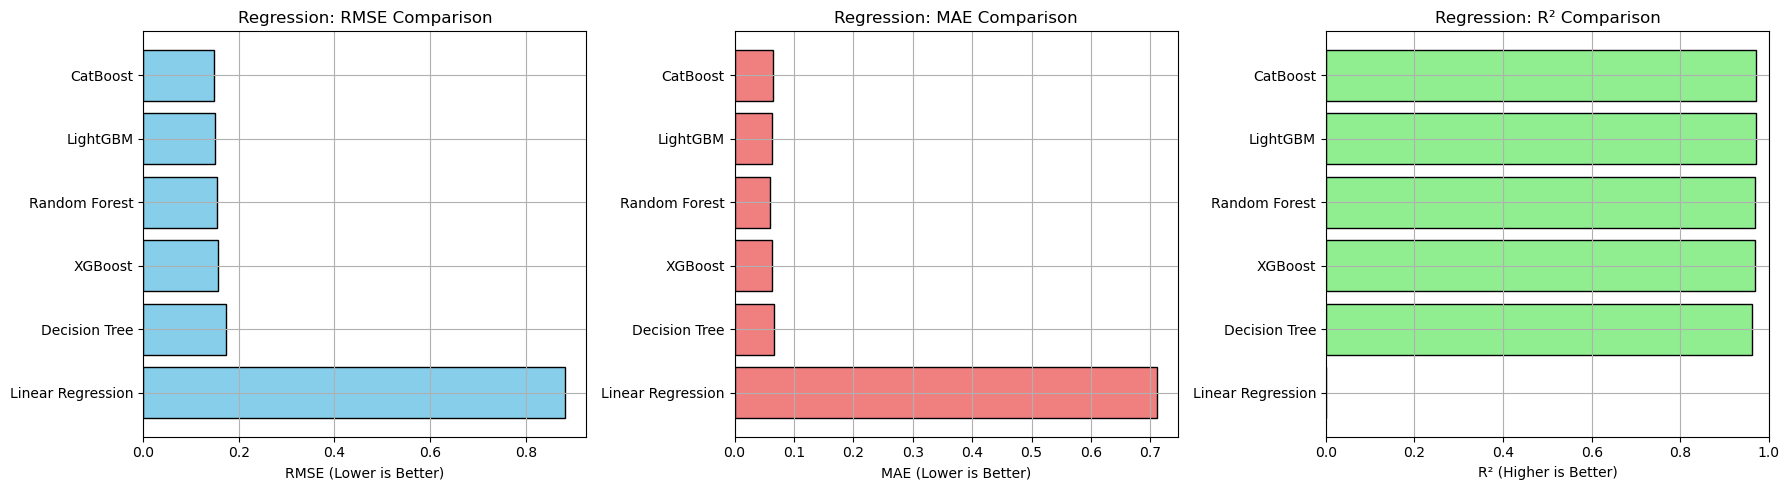

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE
axes[0].barh(df_reg_sorted['Model'], df_reg_sorted['RMSE'], color='skyblue', edgecolor='black')
axes[0].set_title('Regression: RMSE Comparison')
axes[0].set_xlabel('RMSE (Lower is Better)')
axes[0].invert_yaxis()

# MAE
axes[1].barh(df_reg_sorted['Model'], df_reg_sorted['MAE'], color='lightcoral', edgecolor='black')
axes[1].set_title('Regression: MAE Comparison')
axes[1].set_xlabel('MAE (Lower is Better)')
axes[1].invert_yaxis()

# R²
axes[2].barh(df_reg_sorted['Model'], df_reg_sorted['R²'], color='lightgreen', edgecolor='black')
axes[2].set_title('Regression: R² Comparison')
axes[2].set_xlabel('R² (Higher is Better)')
axes[2].set_xlim(0, 1)
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

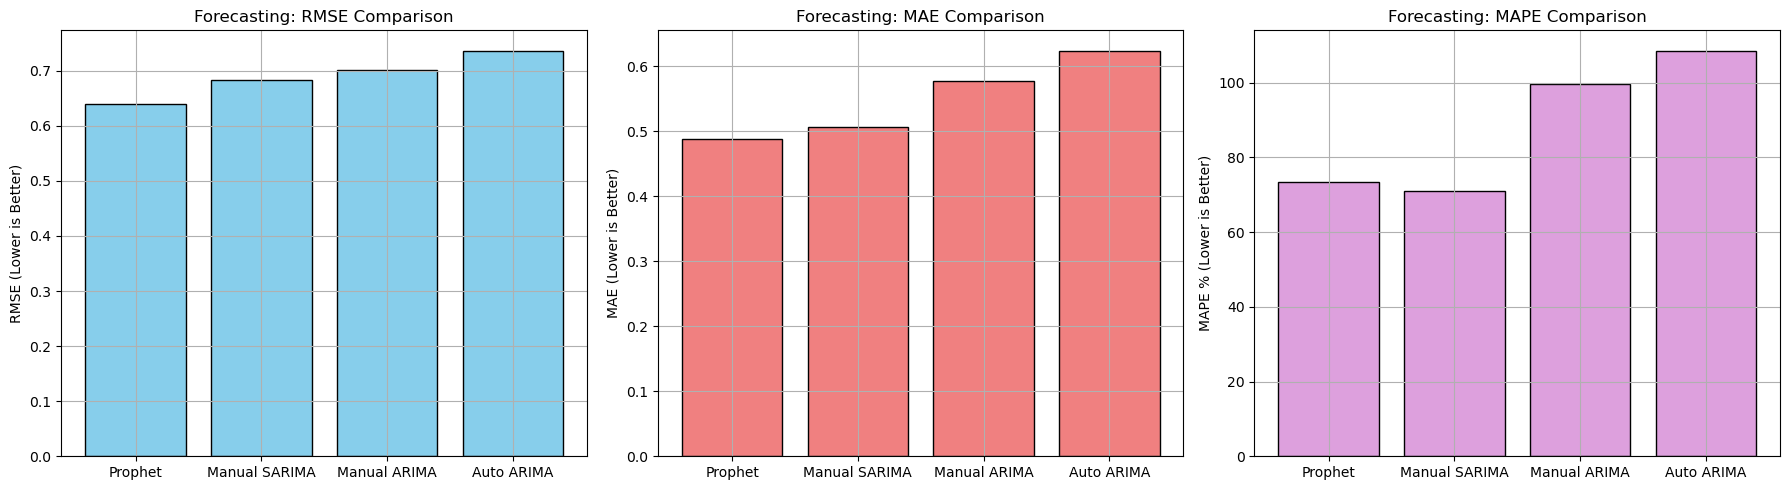

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE
axes[0].bar(df_ts_sorted['Model'], df_ts_sorted['RMSE'], color='skyblue', edgecolor='black')
axes[0].set_title('Forecasting: RMSE Comparison')
axes[0].set_ylabel('RMSE (Lower is Better)')

# MAE
axes[1].bar(df_ts_sorted['Model'], df_ts_sorted['MAE'], color='lightcoral', edgecolor='black')
axes[1].set_title('Forecasting: MAE Comparison')
axes[1].set_ylabel('MAE (Lower is Better)')

# MAPE
axes[2].bar(df_ts_sorted['Model'], df_ts_sorted['MAPE'], color='plum', edgecolor='black')
axes[2].set_title('Forecasting: MAPE Comparison')
axes[2].set_ylabel('MAPE % (Lower is Better)')

plt.tight_layout()
plt.show()

## 6. Best Model Summary
Summary of the best performing models across different categories.

In [11]:
summary_data = [
    {'Category': 'Regression', 'Best Model': 'CatBoost', 'Reason': 'Lowest RMSE (0.1480) and highest R² (0.9715). Tree ensembles completely outperformed Linear Regression.'},
    {'Category': 'Forecasting', 'Best Model': 'Prophet', 'Reason': 'Lowest RMSE (0.6388) and MAE (0.4884) among all tested forecasting models.'}
]

df_summary = pd.DataFrame(summary_data)
df_summary.style.set_properties(**{'text-align': 'left'}).set_table_styles([dict(selector='th', props=[('text-align', 'left')])])

,Category,Best Model,Reason
0,Regression,CatBoost,Lowest RMSE (0.1480) and highest R² (0.9715). Tree ensembles completely outperformed Linear Regression.
1,Forecasting,Prophet,Lowest RMSE (0.6388) and MAE (0.4884) among all tested forecasting models.


## 7. Observations

### Regression Findings
- **Tree-based ensembles (CatBoost, XGBoost, LightGBM, Random Forest, Decision Tree)** significantly outperformed Linear Regression.
- **CatBoost** emerged as the top performer with the lowest RMSE (0.1480) and highest R² (0.9715). LightGBM was a close second.
- **Linear Regression** performed exceptionally poorly (negative R² on test data), indicating it completely failed to capture the non-linear relationships in power consumption data.

### Forecasting Findings
- **Prophet** performed best overall with the lowest RMSE (0.6388) and MAE (0.4884).
- **Manual SARIMA** was the runner-up and the best among ARIMA variants (RMSE 0.6832, AIC 48235), outperforming both Manual and Auto ARIMA.
- Modeling seasonality is critical for this dataset, given the daily and weekly power usage cycles.

### Overall
The ensemble regression models achieved incredibly high predictive accuracy (R² up to 0.97) compared to the pure time series models. This highlights that external features (like weather, day of week, time of day engineered in earlier steps) are incredibly strong predictors for household power consumption.

## 8. Limitations
- **Forecast uncertainty**: Time series forecasts inherently degrade in accuracy for longer horizons. Confidence intervals widen significantly over time.
- **Seasonal assumptions**: SARIMA assumes historical seasonality patterns will remain strictly consistent in the future.
- **Limited external variables**: The dataset lacks certain crucial external factors, such as real-time pricing data or detailed weather conditions (e.g., cloud cover, humidity), which heavily influence power usage.
- **Computational cost**: Advanced models like SARIMA and CatBoost can be computationally intensive to train on large datasets compared to simpler baseline models.
- **Model assumptions**: Linear models assume homoscedasticity and linearity, which were violated in this dataset, leading to their poor performance.

## 9. Future Improvements
- **Deep Learning Approaches**: Implement `LSTM`, `GRU`, or `Transformer`-based forecasting models which excel at capturing long-term dependencies in sequential data.
- **Hyperparameter optimization**: Use Bayesian Optimization (e.g., Optuna) to further fine-tune the CatBoost and XGBoost models.
- **External weather features**: Incorporate detailed localized weather API data (temperature, humidity, sunlight).
- **Holiday effects**: Explicitly model public holidays and local events, which drastically alter power consumption patterns.
- **Real-time deployment**: Develop an API (FastAPI/Flask) to serve the trained CatBoost model and implement `online learning` to continuously update the model with incoming data streams.

## 10. Final Conclusion

This project successfully developed predictive models for **Household Power Consumption Prediction**.

- **Data Processing**: Missing values and anomalies were meticulously cleaned.
- **Feature Engineering**: Extracted temporal features (hour, day, month) and lagged variables which proved vital for model performance.
- **Regression Modelling**: Trained and evaluated 6 regression models. **CatBoost** was identified as the clear winner, achieving the lowest errors and highest R² (0.9715).
- **Time Series Forecasting**: Evaluated ARIMA, SARIMA, and Prophet models. **Prophet** provided the most accurate forecast, with SARIMA being the best statistical alternative.
- **Overall Outcome**: The project demonstrates that while time-series models can map temporal dependencies well, utilizing a strong feature engineering pipeline alongside advanced gradient boosting regression models (like CatBoost and LightGBM) yields the most accurate consumption predictions.